In [78]:
#Biblioteca de manipulação dos dados
import pandas as  pd
from sklearn.impute import SimpleImputer
from scipy.stats.mstats import winsorize
import numpy as np
from sklearn.pipeline import Pipeline

#Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#importação dos modulos
import sys
%load_ext autoreload
%autoreload 2
sys.path.append('../Utils')

#separar os dados em treino e teste
from sklearn.model_selection import train_test_split

#Uteis
from Uteis import TratamentoDados, Graficos

#Filtra warnings
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
utilTratamento = TratamentoDados()
utilGraficos = Graficos()

In [80]:
df = pd.read_csv("../Dados/credit_train.csv")
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [81]:
df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,1.000000e+05,80846.000000,8.084600e+04,100000.000000,100000.000000,46859.000000,100000.00000,100000.000000,1.000000e+05,9.999800e+04,99796.000000,99990.000000
mean,1.176045e+07,1076.456089,1.378277e+06,18472.412336,18.199141,34.901321,11.12853,0.168310,2.946374e+05,7.607984e+05,0.117740,0.029313
std,3.178394e+07,1475.403791,1.081360e+06,12174.992609,7.015324,21.997829,5.00987,0.482705,3.761709e+05,8.384503e+06,0.351424,0.258182
min,1.080200e+04,585.000000,7.662700e+04,0.000000,3.600000,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.796520e+05,705.000000,8.488440e+05,10214.162500,13.500000,16.000000,8.00000,0.000000,1.126700e+05,2.734380e+05,0.000000,0.000000
50%,3.122460e+05,724.000000,1.174162e+06,16220.300000,16.900000,32.000000,10.00000,0.000000,2.098170e+05,4.678740e+05,0.000000,0.000000
75%,5.249420e+05,741.000000,1.650663e+06,24012.057500,21.700000,51.000000,14.00000,0.000000,3.679588e+05,7.829580e+05,0.000000,0.000000
max,1.000000e+08,7510.000000,1.655574e+08,435843.280000,70.500000,176.000000,76.00000,15.000000,3.287897e+07,1.539738e+09,7.000000,15.000000


Agora irei analisar se há valores faltantes. Entretanto, já observei um valor exorbitante de 99999999.0 na variável current score, o que pode ser um indicativo claro de outliers. Tratarei desses casos logo após o tratamento dos valores ausentes.
Mas antes, vou separar os dados em treino e teste — desde que não haja valores vazios na coluna Loan Status, pois essa coluna é essencial para a separação estratificada. Todo e qualquer tratamento que eu fizer no treino será replicado no teste.

In [82]:
df.isna().sum()

Loan ID                           514
Customer ID                       514
Loan Status                       514
Current Loan Amount               514
Term                              514
Credit Score                    19668
Annual Income                   19668
Years in current job             4736
Home Ownership                    514
Purpose                           514
Monthly Debt                      514
Years of Credit History           514
Months since last delinquent    53655
Number of Open Accounts           514
Number of Credit Problems         514
Current Credit Balance            514
Maximum Open Credit               516
Bankruptcies                      718
Tax Liens                         524
dtype: int64

A base de dados apresenta muitos valores faltantes, sendo 514 deles um padrão em quase todas as colunas. Isso pode indicar uma relação entre esses valores ausentes. Para investigar isso mais de perto, pretendo filtrar os valores faltantes e verificar se há algum padrão ou se são apenas valores aleatoriamente ausentes.

In [83]:
dfFaltantes = df[df["Loan ID"].isna() == True]
dfFaltantes


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Como previsto, os valores faltantes correspondem a linhas completamente vazias, evidenciando um padrão claro. Diante disso, irei remover essas linhas ausentes da base de dados para prosseguir com a análise.

In [84]:
dfFaltantes2 = df[~df["Loan ID"].isna() == True]
dfFaltantes2.isna().sum()

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                    19154
Annual Income                   19154
Years in current job             4222
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    53141
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 2
Bankruptcies                      204
Tax Liens                          10
dtype: int64

Após a remoção, vemos que o pradrão dos valores faltantes retirado da base de dados, agora analisarei esses valores de Credit Score e Annual Income que apresentam valores faltantes iguais. Mas antes irei analisar se há duplicatas

In [85]:
dfFaltantes2.duplicated().sum()

10215

Na base de dados, identifiquei um total de 10.215 amostras duplicadas, o que representa uma quantidade significativa e pode impactar negativamente a qualidade do modelo. Para entender melhor, realizei uma investigação para identificar quem são esses clientes com registros duplicados.

In [86]:
duplicatas = dfFaltantes2[dfFaltantes2.duplicated(keep=False)]
duplicatas["Loan Status"].value_counts()


Loan Status
Fully Paid    20430
Name: count, dtype: int64

Como todas as duplicatas pertencem à classe Fully Paid (pagamento efetuado), não há conflito ou ambiguidade na variável alvo nesses registros repetidos. Portanto, esses dados não trazem informação nova para o modelo e podem ser removidos sem impacto negativo no desempenho ou viés do modelo. Isso ajuda a reduzir o tamanho da base e melhora a qualidade dos dados para a modelagem.

In [87]:
dfFaltantes2.drop_duplicates(inplace=True)
dfFaltantes2.duplicated().sum()

0


Feita a remoção dessas duplicatas, posso separar os dados em treino e teste para continuar minha análise dos valores faltantes.

In [88]:
train_df, test_df = train_test_split(dfFaltantes2, test_size=0.2, random_state=42, stratify=dfFaltantes2['Loan Status'])

In [89]:
train_df.isna().sum()

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                    15362
Annual Income                   15362
Years in current job             3056
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    38704
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 0
Bankruptcies                      145
Tax Liens                           5
dtype: int64

Para prosseguir na investigação de Credit Score e Annual Income, é necessário analisar se existe alguma relação com a variável target (Loan Status). Caso eu simplesmente preencha os valores faltantes com a média ou mediana, posso acabar eliminando uma possível correlação. Portanto, antes disso, irei verificar se há alguma diferença nessas duas variáveis em relação à target.

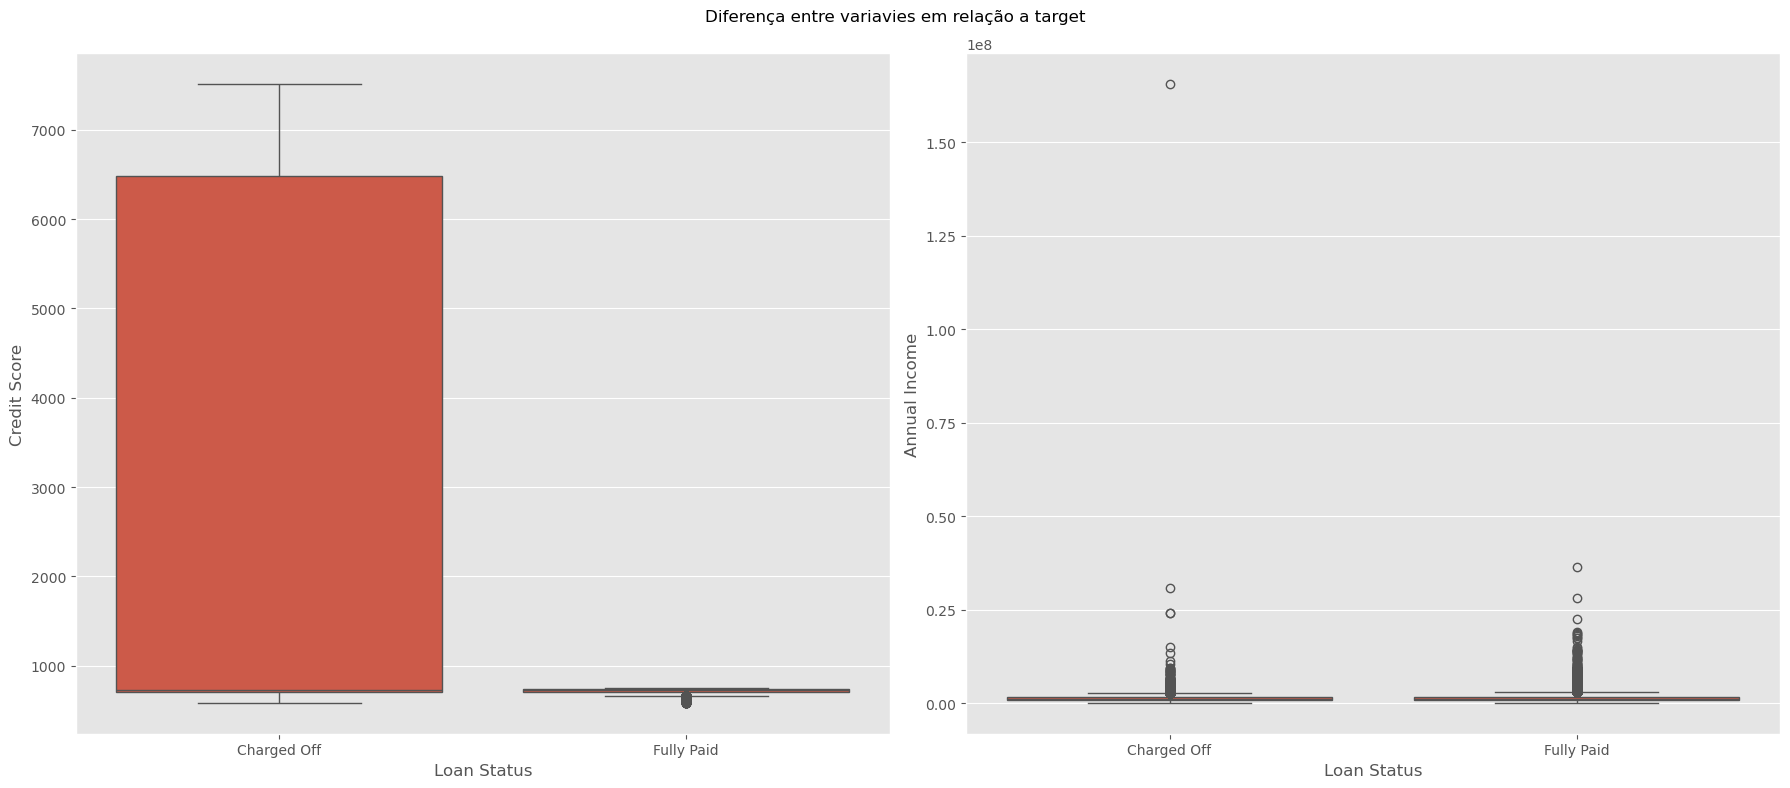

In [90]:
utilGraficos.relacaoDeVariaveisComTargetBoxplot(train_df, ["Credit Score", "Annual Income"], 2, 1)



Após a análise dos gráficos, duas conclusões principais se destacam:

A variável Credit Score apresenta valores muito acima da faixa real (chegando a 6000–7000 pontos, enquanto o esperado seria entre 300 e 850). Esses registros configuram outliers claros e provavelmente erros de dados, e não um comportamento natural da variável. Para evitar que tais valores enviesem o modelo, optei por utilizar a mediana para imputar os valores faltantes, já que ela é menos sensível a extremos e garante um preenchimento mais representativo e neutro entre as classes. Após isso irei remover esses outliers.

A variável Annual Income não apresenta correlação significativa com a variável target (Loan Status). Entretanto, observa-se a presença de um outlier muito expressivo, que pode comprometer o desempenho do modelo. Por esse motivo, optei por tratar esse outlier por meio de winsorization, mas antes realizarei o preenchimento dos valores faltantes com a mediana.

In [91]:
#Vai ser utilizado para preencher os valores vazios com base na mediana
imputar_mediana = SimpleImputer(strategy="median")  


#Aplicando a mediana no treino e no teste
train_df["Credit Score"] = imputar_mediana.fit_transform(train_df[["Credit Score"]])
test_df["Credit Score"] = imputar_mediana.transform(test_df[["Credit Score"]])

train_df["Annual Income"] = imputar_mediana.fit_transform(train_df[["Annual Income"]])
test_df["Annual Income"] = imputar_mediana.transform(test_df[["Annual Income"]])


In [92]:
print(train_df.isna().sum())

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                        0
Annual Income                       0
Years in current job             3056
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    38704
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 0
Bankruptcies                      145
Tax Liens                           5
dtype: int64


Agora irei remover o outlier de Annual Income

In [93]:
np.max(train_df["Annual Income"])

165557393.0

In [94]:
np.max(test_df["Annual Income"])

22448880.0

Durante a análise exploratória, identifiquei que a variável Annual Income apresenta um valor extremamente alto no conjunto de treino (≈165,5 milhões) e outro também elevado no conjunto de teste (≈22,4 milhões). Considerando que, de acordo com o describe(), até o terceiro quartil os valores chegam apenas a cerca de 1,65 milhão, esses máximos representam pontos extremos que destoam fortemente da distribuição.

Manter tais valores poderia enviesar o modelo, principalmente em algoritmos sensíveis a escala e dispersão. Por esse motivo, optei por aplicar winsorization utilizando limites calculados a partir do conjunto de treino, de forma a substituir esses extremos por um valor máximo plausível. Essa abordagem reduz o impacto desses outliers sem removê-los completamente, preservando a variabilidade natural da variável.

In [95]:
train_df = utilTratamento.aplicarWinsorizacao(train_df, ["Annual Income"])
test_df = utilTratamento.aplicarWinsorizacao(test_df, ["Annual Income"])

np.max(train_df["Annual Income"])

4201337.0

In [96]:
np.max(test_df["Annual Income"])

4189500.0

Após o tratamento dos dados, com a redução do impacto do outlier extremo em Annual Income, conseguimos manter um padrão consistente entre os conjuntos de treino e teste. Dessa forma, não há risco de enviesamento nos dados nem diferenças significativas entre os conjuntos:

Valor máximo no treino: 4.201.337

Valor máximo no teste: 4.189.500

Isso garante que o modelo seja treinado e avaliado em distribuições semelhantes, aumentando a confiabilidade dos resultados.

Além disso, para a variável Credit Score, será realizado o tratamento de outliers por meio da remoção de valores acima de 1000, visto que tais registros não representam um score de crédito real e provavelmente decorrem de erros de dados.

In [97]:
train_df = train_df[train_df['Credit Score'] < 1000]
test_df = test_df[test_df['Credit Score'] < 1000]

Com as colunas de Annual Income e Credit Score devidamente tratadas, posso continuar com tratamento dos valores ausentes. Agora irei tratar a variável Years in Current Job, garantindo que os registros fiquem consistentes e que não haja perda de informação relevante devido a dados faltantes.

In [98]:
train_df[train_df["Years in current job"].isna() == True]["Loan Status"].value_counts()

Loan Status
Fully Paid     2029
Charged Off     829
Name: count, dtype: int64

Após a análise dos valores faltantes, percebi que eles não estão associados a nenhuma classe específica. Como representam apenas 4% dos dados totais (3056 de 71828 registros), tratarei esses valores da seguinte forma:
1. Para valores no formato "*n* números de anos + years", extrairei apenas o número do ano.
2. Para valores como "*+10 years*", manterei apenas o número 10.
3. Para valores como "*<0 years*", substituirei por 0.
4. Para campos vazios, utilizarei a mediana para preenchê-los.

Essa abordagem facilitará o pré-processamento, evitando complicações desnecessárias na base de dados, como a criação de colunas adicionais para codificação (*encoding*).

Em seguida, analisarei a coluna *Months since last delinquent* (número de meses desde a última inadimplência registrada), que apresenta uma quantidade significativa de valores vazios, cerca de 52%. Verificarei se esses valores ausentes correspondem a clientes que nunca tiveram inadimplências (ou seja, sempre pagaram seus empréstimos) ou se são aleatórios.

Após a análise, constatei que os valores faltantes não apresentam um padrão claro, o que me indica que posso preencher os valores vazios com a mediana.

In [99]:
#Aqui irá só tratar os dados categoricos em dados numéricos
train_df["Years in current job"] = train_df["Years in current job"].apply(utilTratamento.tratamentoValoresAnosTrabalhoAtual)
test_df["Years in current job"] = test_df["Years in current job"].apply(utilTratamento.tratamentoValoresAnosTrabalhoAtual)

#adicionando a mediana nos valores faltantes
imputar_mediana_years_in_current_job = SimpleImputer(strategy="median")
train_df["Years in current job"] = imputar_mediana.fit_transform(train_df[["Years in current job"]])
test_df["Years in current job"] = imputar_mediana.transform(test_df[["Years in current job"]])

In [100]:
train_df.isna().sum()

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                        0
Annual Income                       0
Years in current job                0
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    36760
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 0
Bankruptcies                      137
Tax Liens                           5
dtype: int64

Agora Vamos analisar o Months since last delinquent, como ele apresenta uma quantidade muito grande de valores faltantes, irei analisar se ele apresenta algum padrão com a target(Loan Status), pois se não houver nenhuma relação irei apagar essa coluna

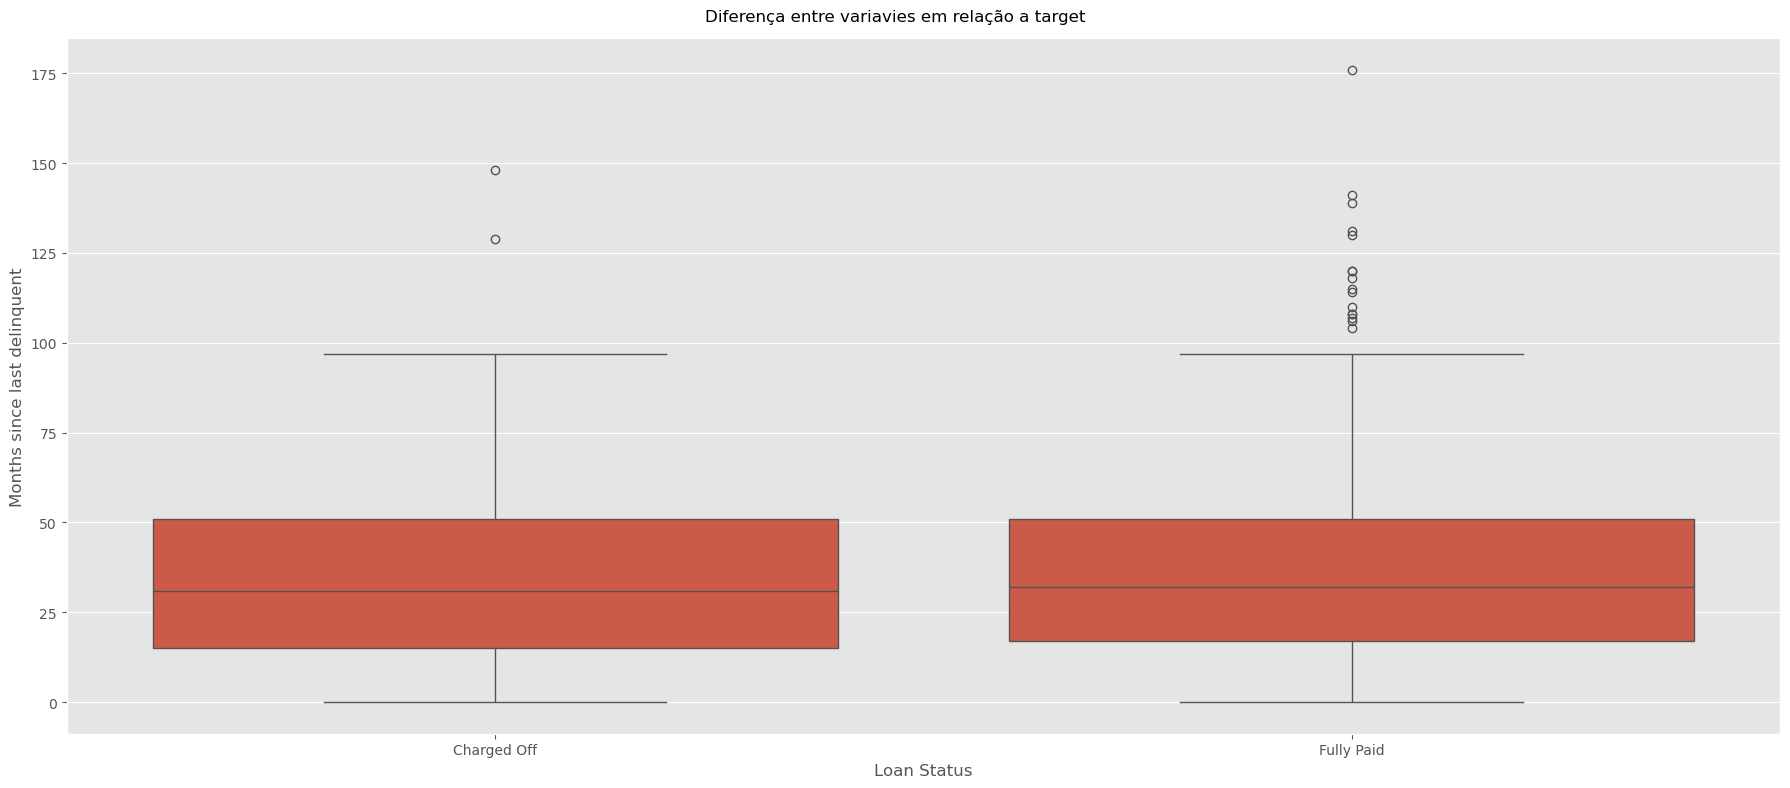

In [101]:
utilGraficos.relacaoDeVariaveisComTargetBoxplot(train_df, ["Months since last delinquent"], 1, 1)

Com base no gráfico, essa coluna não apresenta uma diferença clara em relação à variável target. Portanto, para simplificar o pré-processamento e evitar trabalhos desnecessários de imputação, irei simplesmente removê-la dos conjuntos de treino e teste.


In [102]:
train_df = train_df.drop("Months since last delinquent", axis = 1).copy()
test_df = test_df.drop("Months since last delinquent", axis = 1).copy()

In [103]:

train_df.isna().sum()


Loan ID                        0
Customer ID                    0
Loan Status                    0
Current Loan Amount            0
Term                           0
Credit Score                   0
Annual Income                  0
Years in current job           0
Home Ownership                 0
Purpose                        0
Monthly Debt                   0
Years of Credit History        0
Number of Open Accounts        0
Number of Credit Problems      0
Current Credit Balance         0
Maximum Open Credit            0
Bankruptcies                 137
Tax Liens                      5
dtype: int64

In [104]:
test_df.isna().sum()

Loan ID                       0
Customer ID                   0
Loan Status                   0
Current Loan Amount           0
Term                          0
Credit Score                  0
Annual Income                 0
Years in current job          0
Home Ownership                0
Purpose                       0
Monthly Debt                  0
Years of Credit History       0
Number of Open Accounts       0
Number of Credit Problems     0
Current Credit Balance        0
Maximum Open Credit           1
Bankruptcies                 43
Tax Liens                     4
dtype: int64

Ainda restam alguns valores faltantes, mas sua quantidade é muito pequena. Por isso, posso simplesmente substituí-los pela mediana, já que essa substituição não afetará a análise

In [105]:
# Colunas que você quer imputar
colunas_numericas = ['Maximum Open Credit', 'Bankruptcies', 'Tax Liens']

# Criar pipeline
pipeline_numericas = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Aplicar fit_transform apenas nessas colunas
train_df[colunas_numericas] = pipeline_numericas.fit_transform(train_df[colunas_numericas])
test_df[colunas_numericas] = pipeline_numericas.transform(test_df[colunas_numericas])

In [106]:
train_df.isna().sum()

Loan ID                      0
Customer ID                  0
Loan Status                  0
Current Loan Amount          0
Term                         0
Credit Score                 0
Annual Income                0
Years in current job         0
Home Ownership               0
Purpose                      0
Monthly Debt                 0
Years of Credit History      0
Number of Open Accounts      0
Number of Credit Problems    0
Current Credit Balance       0
Maximum Open Credit          0
Bankruptcies                 0
Tax Liens                    0
dtype: int64

In [107]:
test_df.isna().sum()

Loan ID                      0
Customer ID                  0
Loan Status                  0
Current Loan Amount          0
Term                         0
Credit Score                 0
Annual Income                0
Years in current job         0
Home Ownership               0
Purpose                      0
Monthly Debt                 0
Years of Credit History      0
Number of Open Accounts      0
Number of Credit Problems    0
Current Credit Balance       0
Maximum Open Credit          0
Bankruptcies                 0
Tax Liens                    0
dtype: int64

Agora, com a base de dados com todos os valores preenchidos, irei iniciar a análise exploratória. Antes disso, vou remover um outlier que identifiquei da coluna Current Loan Amount, que possui o valor 99.999.999,0, o qual claramente indica um erro.

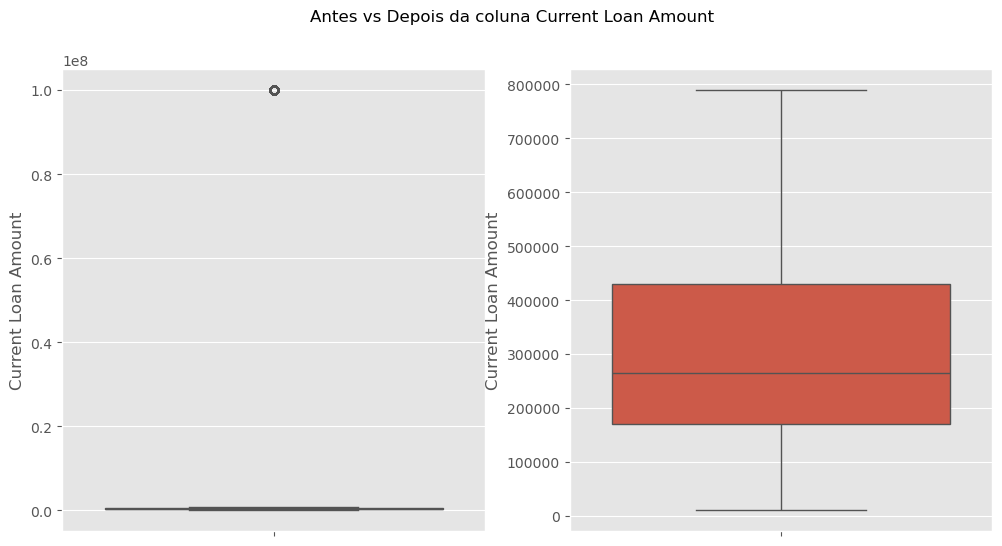

In [108]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)

dados_sem_outlier = train_df[train_df['Current Loan Amount'] < 99999999.0]["Current Loan Amount"]
dados_com_outiler = train_df['Current Loan Amount']
sns.boxplot(dados_com_outiler, ax = axs[0])
sns.boxplot(dados_sem_outlier, ax = axs[1])
plt.suptitle("Antes vs Depois da coluna Current Loan Amount")
plt.tight_layout
plt.show()


Fica evidente que esses outliers estavam distorcendo de forma exagerada a proporção dos dados. Portanto, irei removê-los para não prejudicar a análise exploratória nem comprometer o desempenho do modelo futuramente.

In [109]:
train_df = train_df[train_df['Current Loan Amount'] < 99999999.0]
test_df = test_df[test_df['Current Loan Amount'] < 99999999.0]


## Análise Exploratória de Dados (EDA)

Com a etapa de **tratamento de missing values** concluída, passamos agora para a **análise exploratória de dados (EDA)**.

O objetivo da EDA é compreender melhor o comportamento das variáveis, identificar padrões, relações e potenciais problemas nos dados. A análise exploratória pode ser dividida em três categorias principais:

1. **Univariada**
   Análise de cada variável individualmente, verificando distribuição, medidas de tendência central, dispersão, presença de outliers, entre outros aspectos.

2. **Bivariada**
   Estudo da relação entre duas variáveis, utilizando técnicas como correlações, tabelas cruzadas e gráficos de dispersão.

3. **Multivariada**
   Investigação envolvendo três ou mais variáveis simultaneamente, identificando interações complexas e padrões combinados, frequentemente utilizando visualizações como pairplots e heatmaps de correlação.

Antes de inicar a analise irei retirar as colunas Loan ID e Customer ID que de nada vão me servir na análise.




In [110]:
train_df.drop(columns = ["Loan ID", "Customer ID"], axis =1, inplace = True)
test_df.drop(columns = ["Loan ID", "Customer ID"], axis =1, inplace = True)

## Análise Univariada

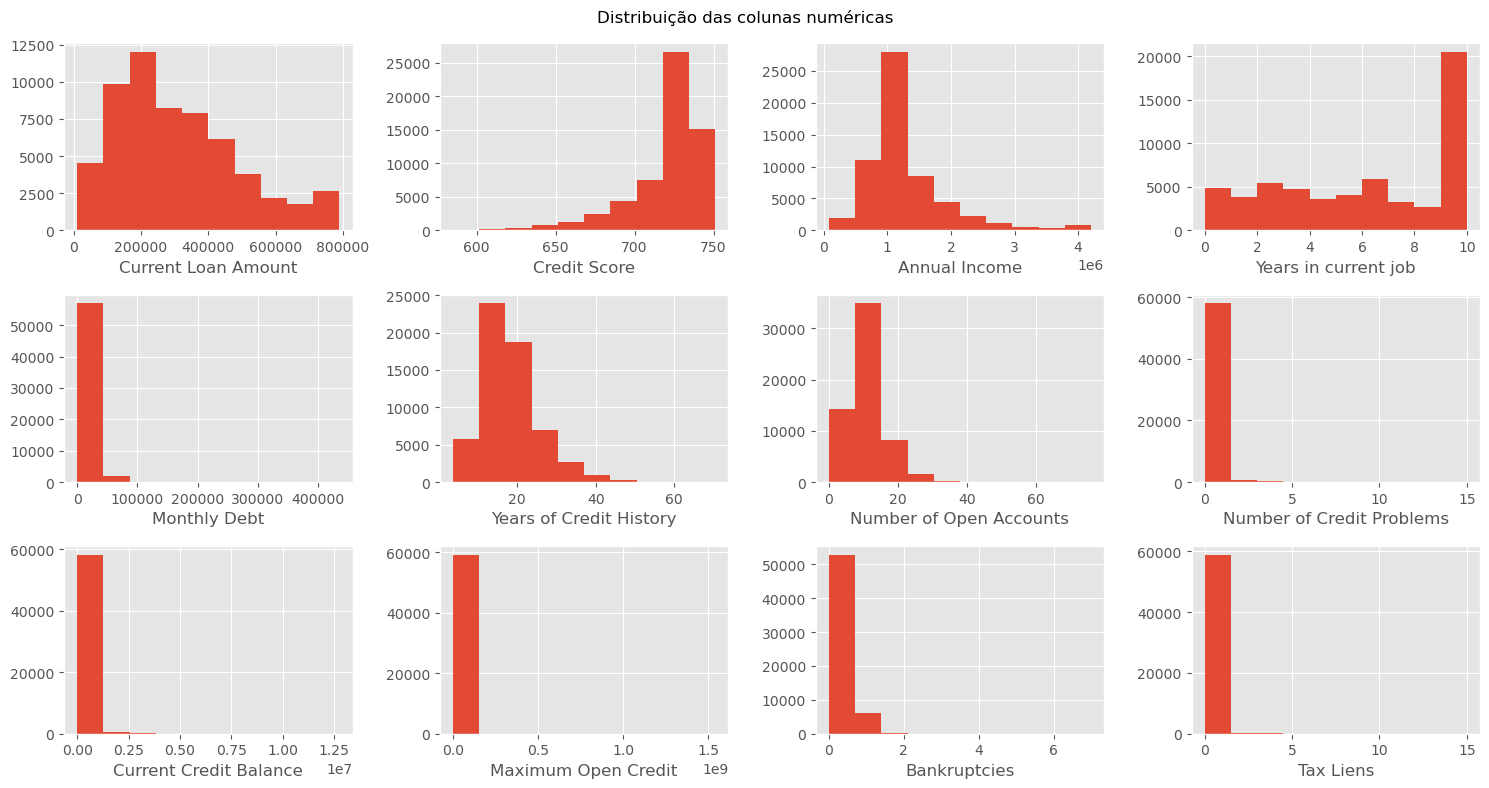

In [111]:
utilGraficos.analiseUnivariada(train_df, "number")


### Análises

1. **Credit Score**

   * A distribuição apresenta assimetria, mas permanece consistente entre as classes.
   * Nesse momento, essa característica não representa preocupação, visto que os dados estão razoavelmente bem distribuídos.

2. **Years in Current Job**

   * Observa-se que muitos clientes possuem **mais de 10 anos no emprego atual**, indicando um perfil com **histórico profissional mais estável**.
   * Essa variável pode ser importante para o modelo, já que estabilidade no emprego costuma estar associada a menor risco de inadimplência.

3. **Monthly Debt**

   * Foi identificado um **outlier extremamente elevado**, possivelmente referente a um único registro discrepante.
   * Esse valor pode distorcer medidas estatísticas (como média e desvio-padrão) e impactar negativamente o treinamento do modelo, tornando necessário seu tratamento.

4. **Current Credit Balance & Maximum Open Credit**

   * Ambas as variáveis apresentam **outliers significativos**.
   * Esses valores precisam ser analisados individualmente, verificando se representam **erros de registro** ou apenas clientes atípicos, mas válidos.
   * Dependendo da análise, o tratamento pode ser feito por **winsorization, remoção seletiva ou transformação logarítmica**.

5. **Demais Variáveis**

   * Não foram identificados pontos adicionais relevantes neste momento da análise exploratória.



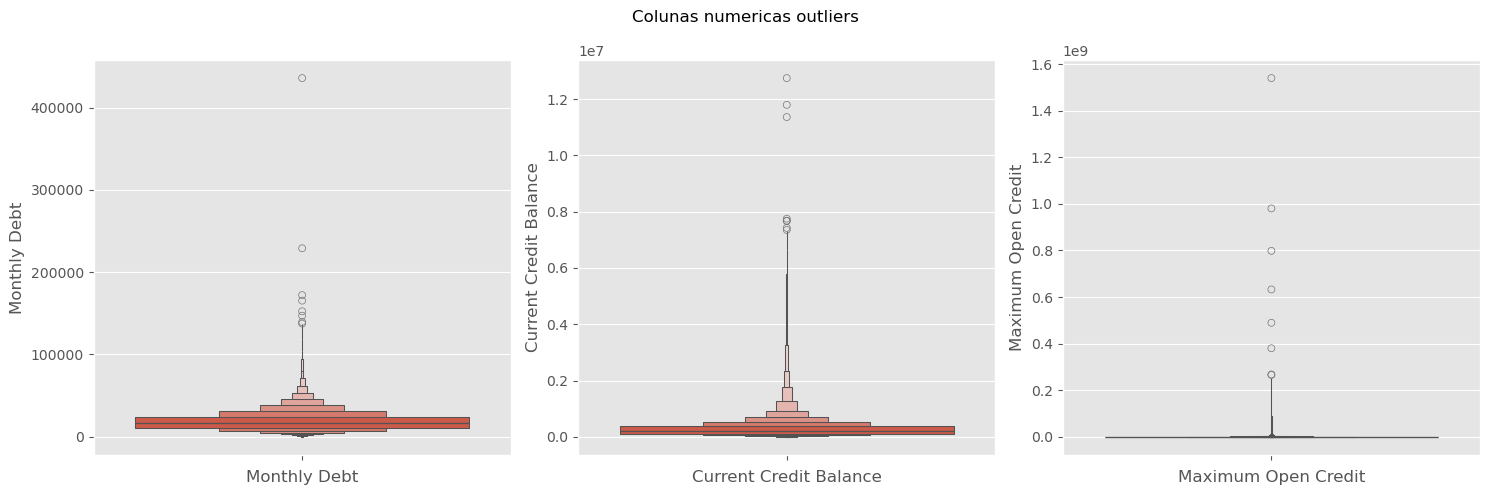

In [112]:
utilGraficos.analiseUnivariadaBoxPlot(train_df, ["Monthly Debt", "Current Credit Balance", "Maximum Open Credit"])

Essas três variáveis apresentam outliers bastante significativos que podem impactar negativamente o desempenho do modelo, principalmente ao influenciar medidas de tendência central e dispersão. Portanto, será necessário aplicar técnicas de tratamento (como Winsorization, remoção ou transformação logarítmica) para reduzir o efeito desses valores extremos e manter a robustez da análise.

In [113]:
train_df = utilTratamento.aplicarWinsorizacao(train_df, ["Monthly Debt", "Current Credit Balance", "Maximum Open Credit"])
test_df = utilTratamento.aplicarWinsorizacao(test_df, ["Monthly Debt", "Current Credit Balance", "Maximum Open Credit"])

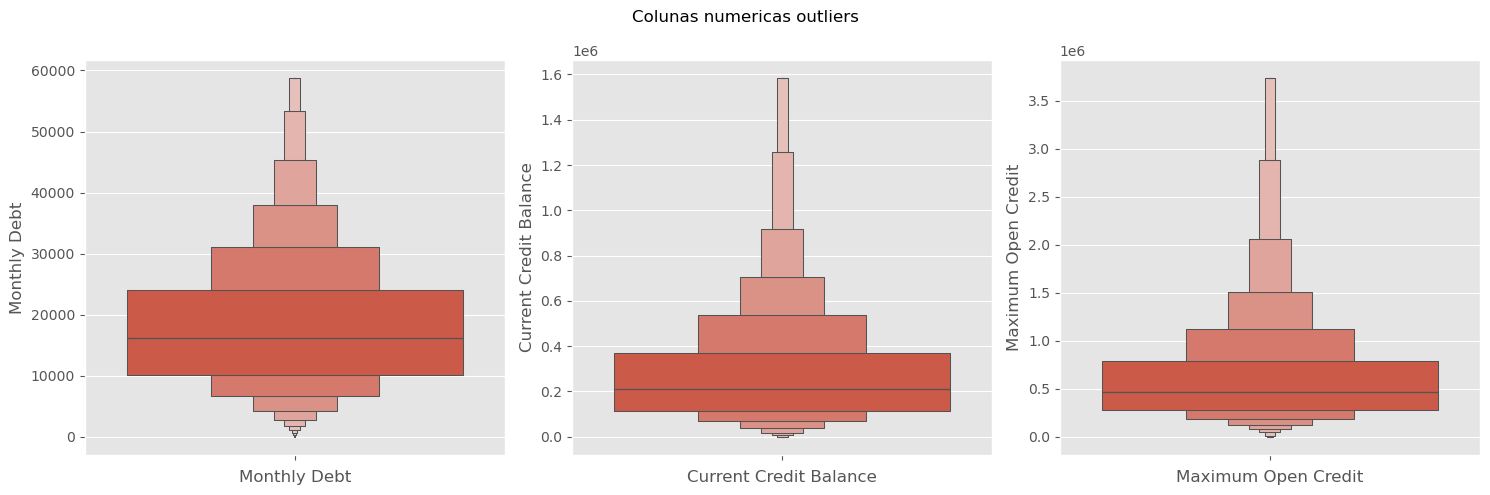

In [114]:
utilGraficos.analiseUnivariadaBoxPlot(train_df, ["Monthly Debt", "Current Credit Balance", "Maximum Open Credit"])

Com o tratamento dos outliers concluído por meio da técnica de Winsorization, as variáveis foram ajustadas e os valores extremos suavizados. Dessa forma, os dados estão mais consistentes e preparados, permitindo prosseguir com a análise exploratória e modelagem sem risco de distorções significativas. Agora irei partir para a análise univariada  das variaveis categóricas.

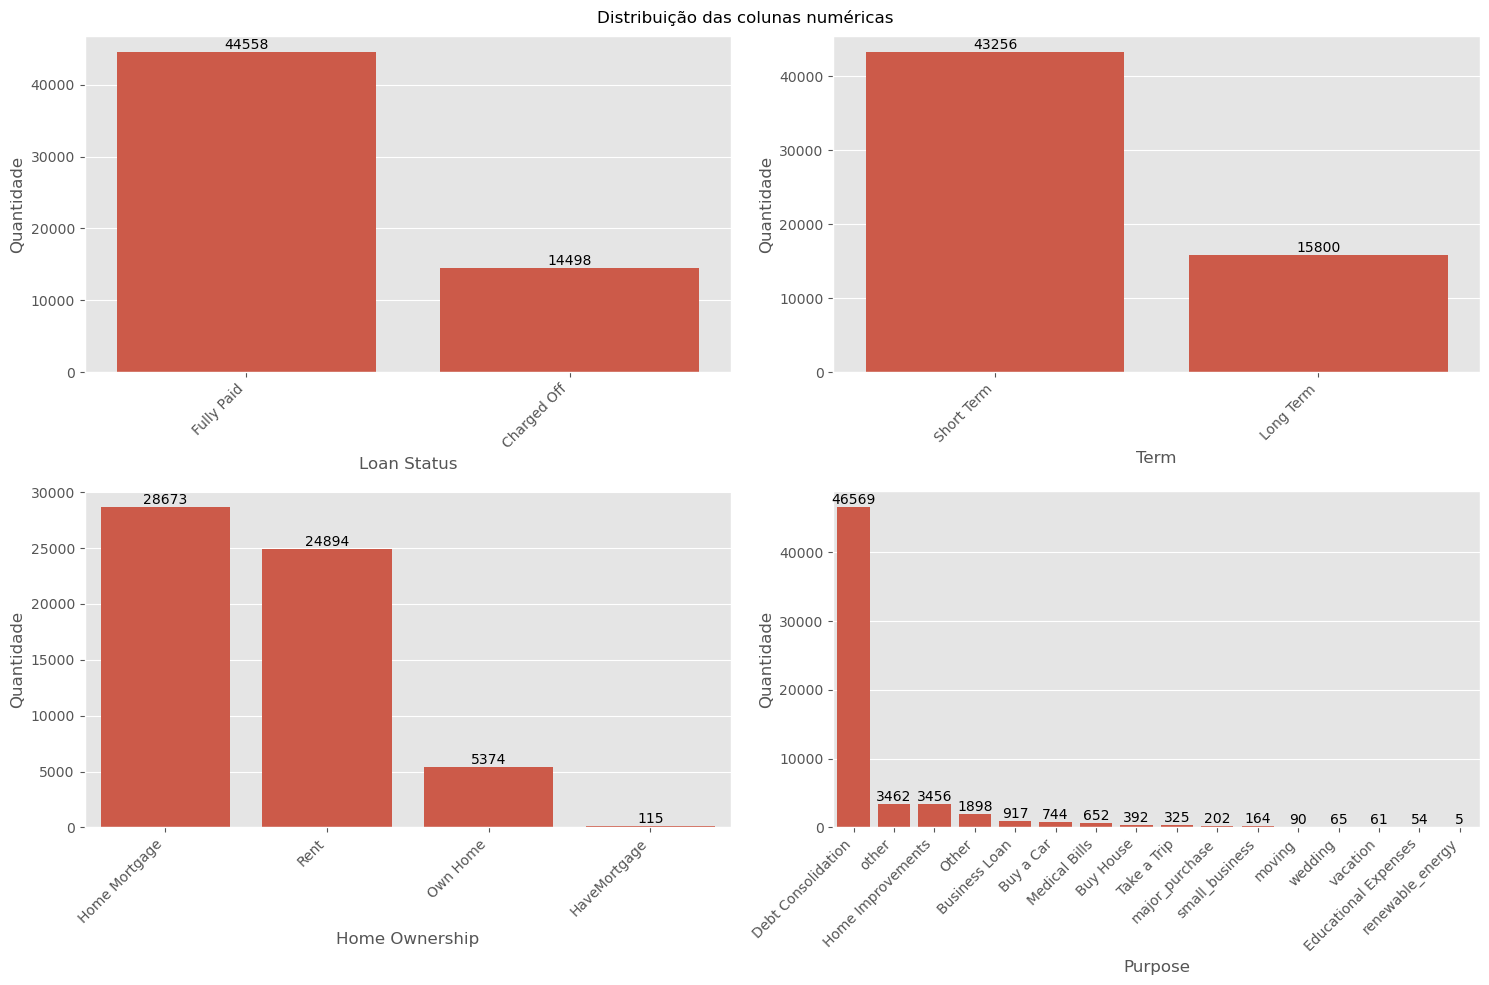

In [115]:
utilGraficos.analiseUnivariada(train_df, "object")



### Análises

1. **Status de Empréstimos**

   * Observa-se que há uma quantidade significativamente maior de clientes que **pagaram** seus empréstimos em comparação com os que **não pagaram**.
   * Esse comportamento é esperado em cenários de crédito, já que instituições financeiras normalmente aprovam clientes com maior probabilidade de pagamento.
   * Esse desbalanceamento nas classes indica que a **acurácia não é a métrica mais adequada** para avaliar o desempenho de um modelo preditivo, sendo preferível utilizar métricas como **Precisão, Recall, F1-Score ou AUC-ROC**.

2. **Term (Prazo do Empréstimo)**

   * A variável mostra predominância de empréstimos com **short term** em relação a **long term**.
   * Isso sugere que os clientes preferem empréstimos de **curto prazo**, possivelmente para evitar pagamento de juros elevados ou por restrições de aprovação.
   * Do ponto de vista da instituição financeira, prazos menores reduzem riscos de inadimplência ao encurtar o tempo de exposição do crédito.

3. **Home Ownership (Propriedade da Casa)**

   * A maioria dos clientes está distribuída principalmente entre **"Home Mortgage"** e **"Rent"**.
   * Isso mostra que grande parte dos solicitantes não possuem casa própria quitada, o que pode influenciar diretamente no risco de crédito, já que o patrimônio do cliente é menor.
   * Esse fator é relevante para análise de risco, visto que clientes com imóvel próprio quitado geralmente representam menor risco para a instituição.

4. **Purpose (Finalidade do Empréstimo)**

   * Nota-se que a finalidade mais frequente é **Debt Consolidation** (consolidação de dívidas).
   * Isso indica que muitos clientes buscam empréstimos para **reunir e refinanciar dívidas anteriores**, possivelmente visando melhores condições de pagamento ou taxas de juros mais baixas.
   * Esse perfil sugere um público que já apresenta histórico de endividamento, podendo influenciar no risco de inadimplência.


# Análise Bivariada 

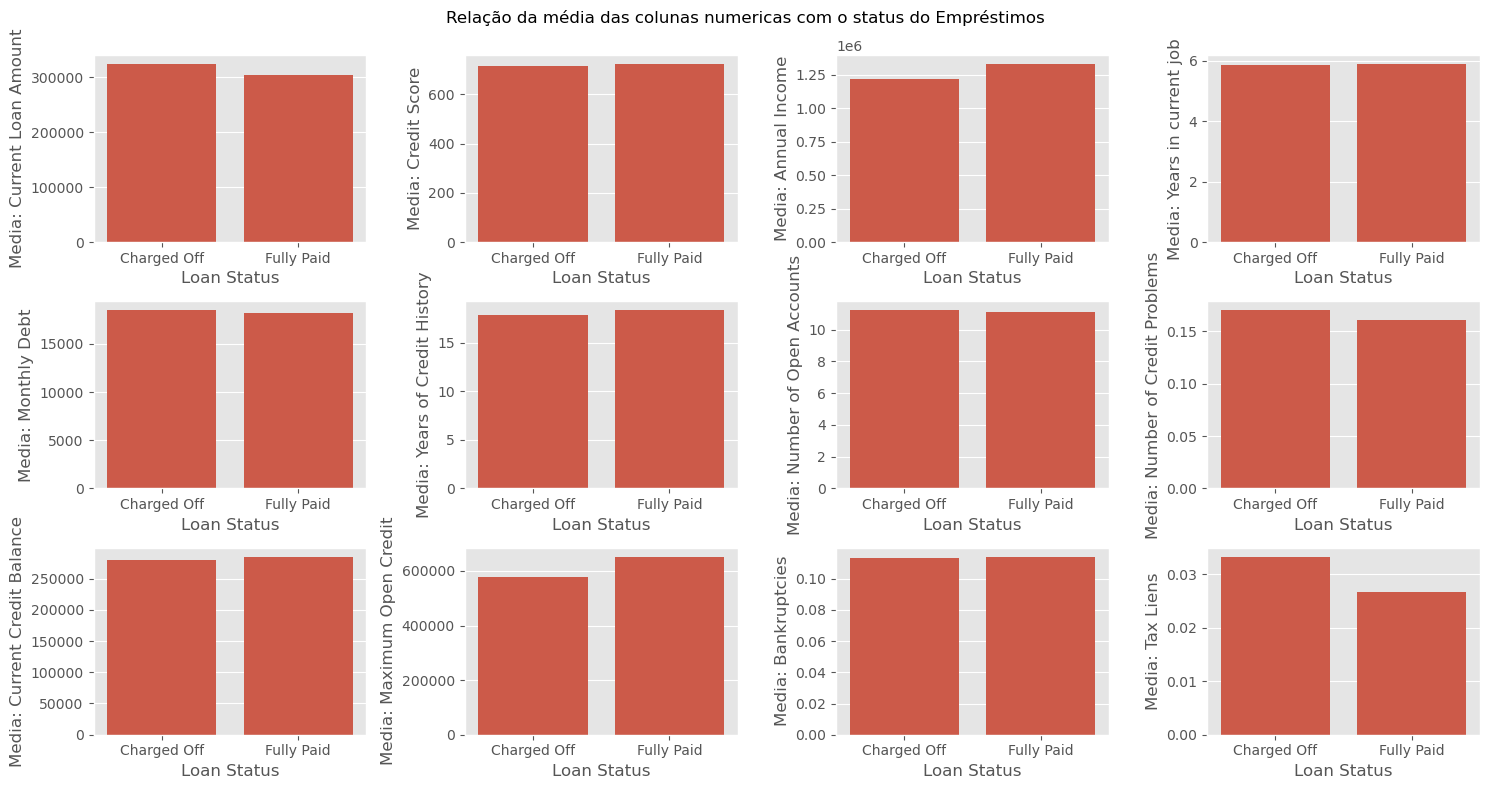

In [116]:
utilGraficos.analiseBivariada(train_df, "number")

Após a análise das variáveis numéricas, não foram identificadas diferenças significativas entre as classes que justifiquem decisões específicas neste momento. Assim, o próximo passo será a análise das variáveis categóricas, a fim de investigar padrões de comportamento e possíveis relações com a variável target.

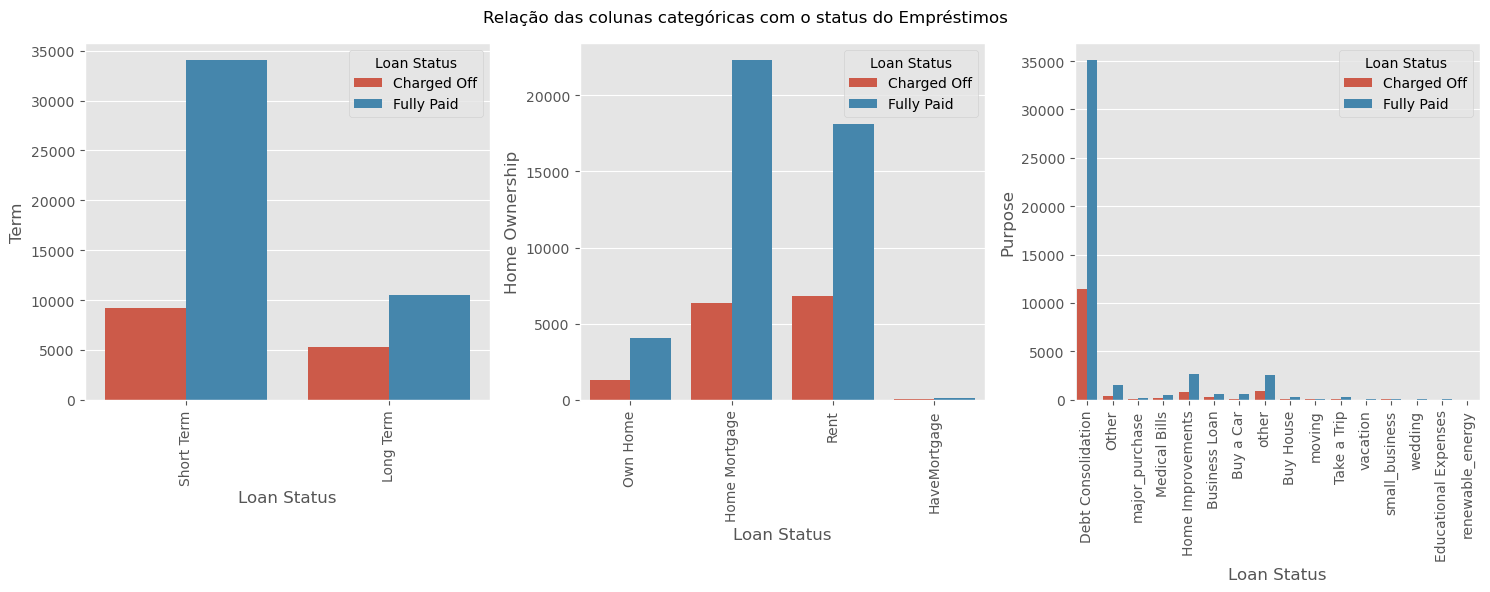

In [117]:
utilGraficos.analiseBivariada(train_df, "object")


###  Análise das variáveis categóricas em relação ao *Loan Status*

1. **Term (prazo do empréstimo)**

   * Observa-se que a proporção de inadimplência é **maior nos contratos de Long Term** do que em Short Term.
   * Isso indica que quanto maior o prazo, maior a probabilidade do cliente não conseguir honrar os pagamentos, possivelmente pela maior exposição ao risco ao longo do tempo.
   * Ou seja, “Long Term” pode ser considerado um fator de risco adicional.

2. **Purpose (finalidade do empréstimo)**

   * A categoria **Debt Consolidation** concentra a maior parte dos empréstimos e, consequentemente, também a maior quantidade absoluta de inadimplentes.
   * No entanto, para uma análise justa, é preciso olhar **proporções**: outras finalidades como *Medical Bills* ou *Small Business* apresentam taxas de inadimplência relativamente altas, mesmo que o número total de casos seja menor.
   * Isso mostra que **nem sempre o maior volume é o mais arriscado**, e que categorias menores também podem ser relevantes para o risco, apesar de terem menos impacto agregado.

3. **Home Ownership (situação de moradia)**

   * Clientes que **moram de aluguel (Rent)** apresentam níveis de inadimplência similares aos que  possuem **hipoteca (Home Mortgage)**.
   * Apesar de pequenas variações, não parece haver uma diferença tão acentuada entre essas categorias, sugerindo que o *Loan Status* não está fortemente associado à posse de imóvel.


---

###  Conclusões e próximos passos

* **Conclusões principais:**

  * *Long Term* → maior risco de inadimplência em termos proporcionais.
  * *Debt Consolidation* → principal fonte de risco agregado pela quantidade de clientes, mas outras categorias menores (como *Medical Bills* ou *Small Business*) também apresentam altas taxas proporcionais.
  * *Home Ownership* → não apresenta diferenças marcantes, podendo ter impacto limitado no modelo.

* **Próximos passos:**

  1. Refazer os gráficos em termos **proporcionais (%)** para confirmar quais categorias realmente apresentam maior risco relativo.
  2. Aplicar **teste qui-quadrado** para verificar se as diferenças entre categorias e inadimplência são estatisticamente significativas.


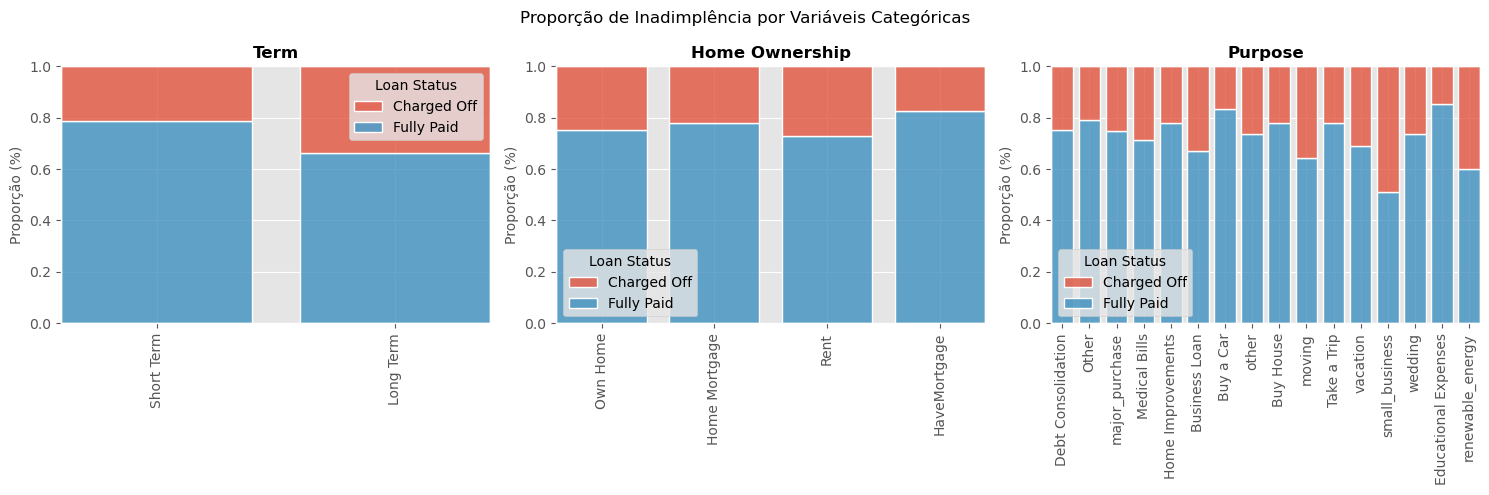

In [118]:
utilGraficos.analisePercentualCategoricasTarget(train_df)



### Análise dos gráficos das variáveis categóricas

Após a análise dos gráficos das variáveis categóricas em relação ao *Loan Status*, algumas observações importantes podem ser destacadas:

1. **Prazo do empréstimo (Term)**

   * Clientes que possuem contratos de **Long Term** apresentam uma **quantidade maior de inadimplentes** quando comparados aos contratos de **Short Term**.
   * Além disso, a **proporção de inadimplência também é mais alta** nos contratos de longo prazo, o que sugere uma relação direta entre o prazo estendido e o risco de não pagamento.
   * Esse comportamento é esperado, já que prazos maiores aumentam a exposição a imprevistos financeiros.

2. **Finalidade do empréstimo (Purpose)**

   * A categoria **Debt Consolidation** concentra o maior volume de clientes e, por consequência, o maior número absoluto de inadimplentes. Isso a torna especialmente relevante do ponto de vista do impacto agregado.
   * Já a categoria **Business Loan**, apesar de contar com apenas **910 registros**, apresenta uma **taxa de inadimplência próxima de 40%**, o que a torna preocupante em termos proporcionais.
   * A categoria **Small Business**, por sua vez, possui apenas **164 registros**, mas quase **50% de inadimplência**, reforçando o perfil de alto risco relativo, embora seu impacto global seja limitado devido à baixa representatividade no conjunto de dados.

---

### Conclusões

* **Long Term** → apresenta maior risco tanto em números absolutos quanto proporcionais, indicando que prazos longos elevam a probabilidade de inadimplência.
* **Debt Consolidation** → representa a maior preocupação em termos de impacto agregado, já que reúne o maior volume de clientes inadimplentes.
* **Business Loan** e **Small Business** → categorias menores em volume, mas que exibem **taxas muito altas de inadimplência**, configurando risco elevado em termos proporcionais.

---


### Testes Estatísticos

Nesta etapa, o objetivo é verificar **se existe relação estatisticamente significativa** entre as variáveis independentes e a variável alvo (**Loan Status**). Para isso, utilizamos testes distintos conforme o tipo de variável:

1. **Variáveis categóricas**

   * Aplicado o **Teste Qui-Quadrado de Independência**.
   * H0: não há associação entre a variável categórica e o Loan Status.
   * p < 0.05 → rejeitamos H0 → existe associação significativa.

2. **Variáveis numéricas**

   * Primeiramente, foi avaliada a **normalidade** das distribuições (Shapiro-Wilk).
   * Como a maioria não segue distribuição normal, irei utilizar o **teste não paramétrico de Mann-Whitney U** para comparação entre os grupos (**Fully Paid** x **Charged Off**).
   * H0: não há diferença entre as distribuições dos grupos.
   * p < 0.05 → rejeitamos H0 → a variável apresenta diferença significativa entre inadimplentes e adimplentes.



In [119]:
import pandas as pd
import scipy.stats as stats

categorical_vars = ['Term', 'Purpose', 'Home Ownership']

for var in categorical_vars:
    print(f"\nTeste Qui-Quadrado entre {var} e Loan_Status:")

    # Tabela de contingência
    contingency_table = pd.crosstab(train_df[var], train_df['Loan Status'])
    print(contingency_table)

    # Aplicando o teste
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"Chi² = {chi2:.2f}")
    print(f"p-valor = {p:.5f}")
    print(f"Graus de liberdade = {dof}")
    
    if p < 0.05:
        print("➡️ Existe associação significativa entre as variáveis.")
    else:
        print("➡️ Não há evidências de associação significativa.")



Teste Qui-Quadrado entre Term e Loan_Status:
Loan Status  Charged Off  Fully Paid
Term                                
Long Term           5321       10479
Short Term          9177       34079
Chi² = 969.58
p-valor = 0.00000
Graus de liberdade = 1
➡️ Existe associação significativa entre as variáveis.

Teste Qui-Quadrado entre Purpose e Loan_Status:
Loan Status           Charged Off  Fully Paid
Purpose                                      
Business Loan                 303         614
Buy House                      86         306
Buy a Car                     124         620
Debt Consolidation          11452       35117
Educational Expenses            8          46
Home Improvements             759        2697
Medical Bills                 186         466
Other                         398        1500
Take a Trip                    72         253
major_purchase                 51         151
moving                         32          58
other                         909        2553
ren


### Conclusão geral

* Todas as variáveis categóricas analisadas (**Term, Purpose, Home Ownership**) apresentaram associação estatisticamente significativa com a variável alvo (**Loan Status**).
* Isso indica que elas devem ser **mantidas no modelo** e provavelmente terão **relevância preditiva**.
* Para complementar, seria interessante calcular uma medida de **força da associação** (como o **Cramér’s V**) a fim de identificar quais variáveis têm maior peso relativo.

### Próximos passos da EDA

Como as variáveis numéricas não mostraram diferenças significativas, não será necessário aprofundar os testes estatísticos nelas neste momento.
Para finalizar a análise exploratória, será feita uma avaliação conjunta de **Term e Loan Status em relação ao Current Loan Amount**, com foco em entender os riscos financeiros associados, especialmente no caso dos contratos **Long Term**, que apresentam maior proporção de inadimplência.






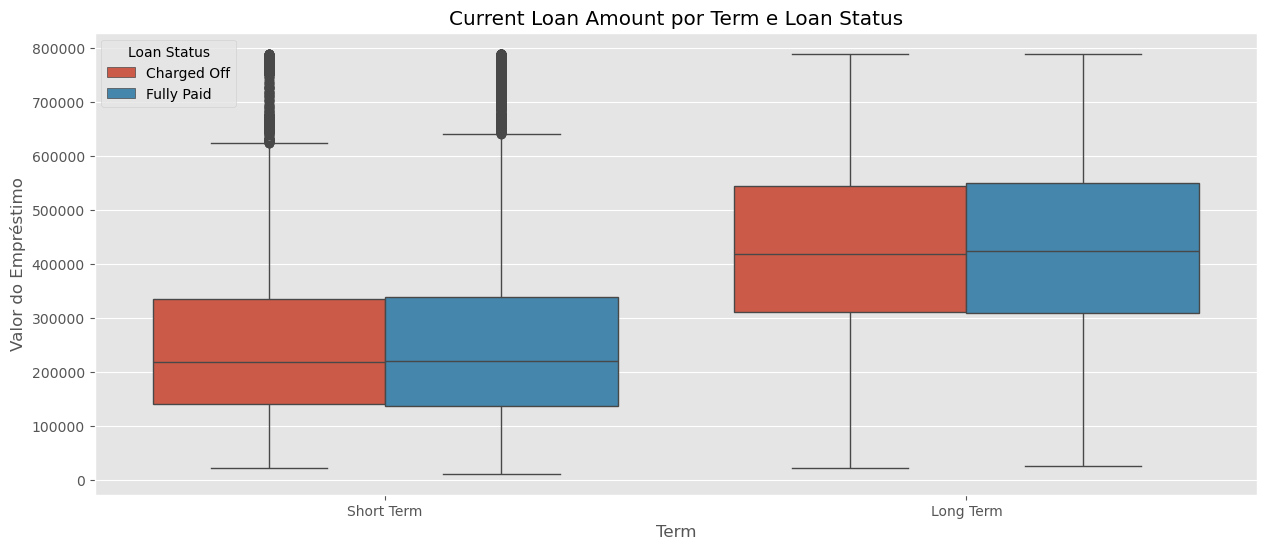

In [132]:
plt.figure(figsize=(15,6))

# Boxplot mostrando Current Loan Amount por Term e Loan Status
sns.boxplot(
    x='Term', 
    y='Current Loan Amount', 
    hue='Loan Status', 
    data=train_df
)

plt.title("Current Loan Amount por Term e Loan Status")
plt.ylabel("Valor do Empréstimo")
plt.show()

### Risco por prazo do empréstimo

A análise mostra que os empréstimos de Long Term apresentam maior risco para a instituição financeira. Isso acontece porque, além de envolverem valores médios de empréstimo mais altos, eles também concentram uma proporção significativamente maior de inadimplência quando comparados aos contratos de Short Term.

Nos Short Term, embora também haja inadimplência, os valores de empréstimos são menores e, portanto, o impacto financeiro de cada contrato não pago tende a ser menos expressivo. Isso significa que, mesmo que a taxa de inadimplência não seja desprezível, a exposição total da instituição em termos de perda financeira é mais limitada.

No caso dos Long Term, o cenário é mais crítico. O prazo maior pode estar associado a um risco de crédito adicional, já que compromissos de longo prazo são mais vulneráveis a mudanças nas condições econômicas ou pessoais do cliente. Além disso, como esses empréstimos envolvem montantes maiores, cada inadimplência representa uma perda mais significativa em termos absolutos.

Portanto, os contratos de longo prazo combinam duas dimensões de risco: maior frequência de inadimplência e maior exposição financeira em cada contrato. Esse duplo efeito torna os Long Term uma categoria particularmente sensível e que merece maior atenção na gestão de risco de crédito.

Agora irei salvar os dataset de treino e testes para a criação do modelo preditivo

In [133]:
train_df.to_csv("../Dados/train.csv")
test_df.to_csv("../Dados/test.csv")



## Conclusão da Análise Exploratória (EDA)

A análise exploratória revelou padrões importantes na relação entre características dos clientes, tipo de contrato e risco de inadimplência:

1. **Prazo do empréstimo (Term)**

   * Contratos de **Long Term** apresentaram maior proporção de inadimplência e também envolveram valores mais altos de empréstimos.
   * Esse duplo efeito (maior frequência de inadimplentes + maior exposição financeira) torna os contratos de longo prazo os mais críticos em termos de risco.

2. **Finalidade do empréstimo (Purpose)**

   * **Debt Consolidation** se destacou pelo impacto agregado: concentra o maior número absoluto de inadimplentes por ser a categoria mais frequente.
   * **Business Loan** e **Small Business**, apesar do baixo volume de registros, apresentaram taxas de inadimplência extremamente elevadas (cerca de 40% e 50%, respectivamente), configurando alto risco proporcional.

3. **Home Ownership**

   * Clientes em situação de **Rent** e **Own Home** mostraram maior probabilidade de inadimplência.
   * Já aqueles em **Home Mortgage** apresentaram menor risco relativo, sugerindo que a posse de um imóvel financiado pode estar ligada a maior estabilidade financeira.

4. **Variáveis numéricas**

   * Não apresentaram diferenças estatisticamente significativas entre clientes adimplentes e inadimplentes, indicando que não tiveram o mesmo poder explicativo que as variáveis categóricas.

---

### Insight final

De modo geral, a EDA mostra que variáveis como **prazo do contrato, finalidade do empréstimo e tipo de moradia** possuem forte relação com o risco de inadimplência.
Essas variáveis devem ser consideradas prioritárias em futuros **modelos preditivos de crédito** e em **estratégias de gestão de risco**, especialmente no monitoramento de clientes com contratos longos, finalidades ligadas a negócios e sem imóvel financiado, que se mostraram os perfis mais vulneráveis.
